# Fast Food Marketing Campaign: A/B Test Analysis

**Author:** Hussein Loubani  
**Module 2 . Sprint 2** | Turing College . Data Science Programme

> A fast food chain tested three promotions across stores for four weeks.  
> Each store used exactly one promotion during the test window.

---

## Table of Contents

1. Imports and Setup  
2. Goal and Target Metric  
3. Data Loading  
4. Data Cleaning (missing values, duplicates, type coercion)  
5. Metric Construction (store-level aggregation)  
6. Sample Ratio Mismatch (SRM) Check  
7. Covariate Balance Check  
8. Exploratory Data Analysis  
9. Pairwise A/B Tests (Promo 1 vs 2, 1 vs 3)  
10. A/B/C Global Test (all three promotions)  
11. Business Impact Estimation  
12. Decision and Recommendation  
13. Dashboard  
14. Limitations

---
## 1. Imports and Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Make ab_testing importable from the notebooks/ directory
sys.path.insert(0, str(Path.cwd().parent))

from ab_testing.config import ALPHA, RANDOM_SEED, FAST_FOOD, FIGURES_FF_DIR
from ab_testing.io import load_csv, save_df
from ab_testing.cleaning import clean_fast_food, fast_food_store_level
from ab_testing.stats import (
    welch_ttest_mean,
    bootstrap_ci_mean_diff,
    choose_global_test,
    pairwise_tests,
    srm_check,
)
from ab_testing.plotting import (
    set_plot_style,
    plot_group_mean_bar,
    plot_weekly_trend,
    plot_distribution_violin,
    dashboard_fast_food,
)
from ab_testing.reporting import build_fast_food_manager_report

np.random.seed(RANDOM_SEED)
set_plot_style()
pd.set_option('display.max_columns', 50)

alpha = ALPHA

DATA_RAW = Path.cwd().parent / 'data' / 'raw'
DATA_PROCESSED = Path.cwd().parent / 'data' / 'processed'

---
## 2. Goal and Target Metric

### Goal

Which promotion generates the highest sales? The chain wants to identify the best-performing promotion before rolling it out nationwide.

### Target metric

**Store-level average weekly sales** (`SalesInThousands`, averaged over 4 weeks per store).

This metric satisfies the **STEDII** framework:
- **Sensitive:** Sales respond directly to promotional activity.
- **Timely:** Measured weekly, so a 4-week window provides enough signal.
- **Explainable:** Directly maps to revenue, easy for stakeholders to interpret.
- **Directionality:** Higher is better.
- **Independent:** Each store gets exactly one promotion, so observations are independent at the store level.

The dataset has **four weekly rows per store**. Treating each row as independent would violate the independence assumption. Instead, we aggregate to **one row per store** (average across weeks) before testing.

### Statistical standards

| Parameter | Value |
|---|---|
| Significance level | alpha = 0.05 |
| Two-group test | Welch t-test (unequal variances) |
| Three-group test | Global test (ANOVA/Welch/Kruskal depending on assumptions) |
| Multiple comparisons | Holm correction |
| Robustness | Bootstrap CI (20,000 resamples, seed = 42) |

---
## 3. Data Loading

In [2]:
df_raw = load_csv(DATA_RAW / 'WA_Marketing-Campaign.csv')

print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head()

Shape: 548 rows x 7 columns
Columns: ['MarketID', 'MarketSize', 'LocationID', 'AgeOfStore', 'Promotion', 'week', 'SalesInThousands']


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


---
## 4. Data Cleaning

Before any analysis, we check for:
- **Missing values** in key columns
- **Duplicate rows** that could artificially inflate sample sizes
- **Invalid values** (negative sales, unexpected promotion codes)

In [3]:
# Check missing values
print('Missing values per column:')
print(df_raw.isna().sum())
print()

# Check duplicates
n_dup = df_raw.duplicated().sum()
print(f'Exact duplicate rows: {n_dup}')
print()

# Check duplicate stores (a store appearing under multiple promotions would break the design)
stores_per_promo = df_raw.groupby('LocationID')['Promotion'].nunique()
multi_promo = (stores_per_promo > 1).sum()
print(f'Stores assigned to multiple promotions: {multi_promo}')
if multi_promo > 0:
    print('WARNING: Some stores appear under multiple promotions. This violates the experimental design.')
else:
    print('Each store is assigned to exactly one promotion. Design integrity confirmed.')

Missing values per column:
MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64

Exact duplicate rows: 0

Stores assigned to multiple promotions: 0
Each store is assigned to exactly one promotion. Design integrity confirmed.


In [4]:
df_clean, cleaning_report = clean_fast_food(df_raw)

print(f'Rows in:      {cleaning_report.n_rows_in:,}')
print(f'Rows out:     {cleaning_report.n_rows_out:,}')
print(f'Rows dropped: {cleaning_report.n_rows_dropped}')
print(f'Duplicates:   {cleaning_report.n_duplicates}')
print(f'Missing:      {cleaning_report.n_missing}')
print()
for note in cleaning_report.notes:
    print(f'  - {note}')

Rows in:      548
Rows out:     548
Rows dropped: 0
Duplicates:   0
Missing:      0

  - Missing values in key columns: 0
  - Exact duplicate rows: 0
  - Filtered Promotion to 1, 2, 3
  - Coerced numeric columns and removed negative sales


In [5]:
save_df(df_clean, DATA_PROCESSED / 'fast_food_clean.csv')
print(f'Cleaned data saved to data/processed/fast_food_clean.csv')

Cleaned data saved to data/processed/fast_food_clean.csv


---
## 5. Metric Construction

Each store has four weekly observations. To avoid treating repeated measures as independent, we aggregate to **one row per store**: the average of `SalesInThousands` across available weeks.

In [6]:
store_level = fast_food_store_level(df_clean)

print(f'Store-level dataset: {store_level.shape[0]} stores')
store_level.head()

Store-level dataset: 137 stores


,LocationID,Promotion,avg_sales,n_weeks,total_sales
0,1,3,34.4200,4,137.68
1,2,2,29.5450,4,118.18
2,3,1,40.6800,4,162.72
3,4,2,33.7075,4,134.83
4,5,2,29.0025,4,116.01


In [7]:
summary = (
    store_level.groupby(FAST_FOOD.col_promotion, as_index=False)
    .agg(
        n_stores=(FAST_FOOD.col_location_id, 'nunique'),
        mean_avg_sales=('avg_sales', 'mean'),
        median_avg_sales=('avg_sales', 'median'),
        std_avg_sales=('avg_sales', 'std'),
    )
    .sort_values(FAST_FOOD.col_promotion)
)
summary

,Promotion,n_stores,mean_avg_sales,median_avg_sales,std_avg_sales
0,1,43,58.099012,56.0750,16.028223
1,2,47,47.329415,46.6550,14.497097
2,3,47,55.364468,49.8525,16.383866


---
## 6. Sample Ratio Mismatch (SRM) Check

If the planned allocation was equal across three promotions, we expect roughly 1:1:1 store counts. A significant SRM would indicate a problem with randomization.

In [8]:
observed_counts = store_level[FAST_FOOD.col_promotion].value_counts().sort_index().to_dict()
observed_counts = {f'Promotion {k}': v for k, v in observed_counts.items()}

srm = srm_check(observed_counts)

print('SRM Check (chi-square goodness-of-fit, expected 1:1:1)')
print('=' * 50)
for name, count in srm.observed.items():
    print(f'  {name}: {count} stores')
print(f'  Chi-square: {srm.chi2:.3f}')
print(f'  p-value:    {srm.p_value:.4f}')
print()
if srm.mismatch:
    print('WARNING: SRM detected (p < 0.05). The store allocation is imbalanced.')
    print('This could indicate a problem with the experimental design.')
    print('Results should be interpreted with caution. Ideally the test should be relaunched.')
else:
    print('No SRM detected. Store allocation is consistent with equal randomization.')

SRM Check (chi-square goodness-of-fit, expected 1:1:1)
  Promotion 1: 43 stores
  Promotion 2: 47 stores
  Promotion 3: 47 stores
  Chi-square: 0.234
  p-value:    0.8898

No SRM detected. Store allocation is consistent with equal randomization.


---
## 7. Covariate Balance Check

We verify that store characteristics (age, market size) are similar across promotions. This supports the claim that sales differences are driven by the promotion, not by store mix.

In [9]:
store_meta = (
    df_clean.drop_duplicates(FAST_FOOD.col_location_id)
    [[FAST_FOOD.col_location_id, FAST_FOOD.col_promotion, 'MarketSize', 'AgeOfStore']]
)

balance_age = (
    store_meta.groupby(FAST_FOOD.col_promotion, as_index=False)
    .agg(n=('AgeOfStore', 'size'), mean_age=('AgeOfStore', 'mean'), median_age=('AgeOfStore', 'median'))
)

print('Store age by promotion:')
print(balance_age.to_string(index=False))
print()
print('Market size distribution by promotion:')
print(pd.crosstab(store_meta[FAST_FOOD.col_promotion], store_meta['MarketSize']).to_string())

Store age by promotion:
 Promotion  n  mean_age  median_age
         1 43  8.279070         6.0
         2 47  7.978723         7.0
         3 47  9.234043         8.0

Market size distribution by promotion:
MarketSize  Large  Medium  Small
Promotion                       
1              14      24      5
2              16      27      4
3              12      29      6


---
## 8. Exploratory Data Analysis

All plots include numeric labels and sample sizes.

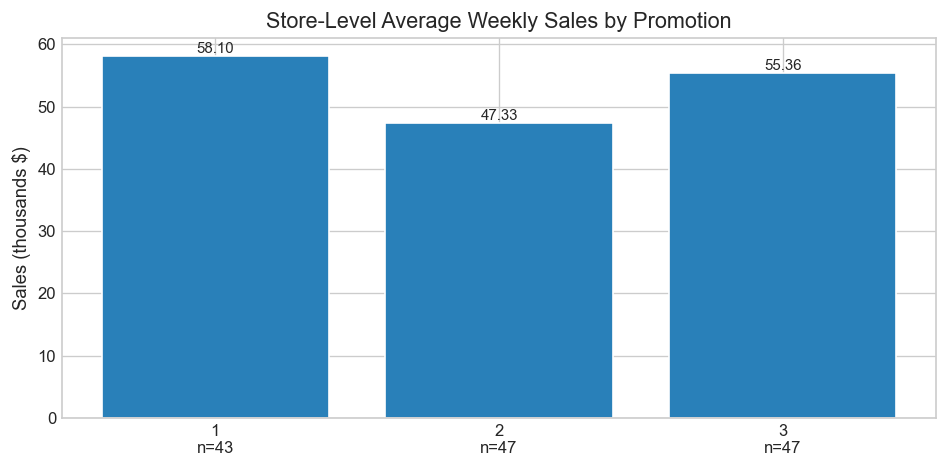

In [10]:
fig = plot_group_mean_bar(
    store_level,
    group_col=FAST_FOOD.col_promotion,
    value_col='avg_sales',
    title='Store-Level Average Weekly Sales by Promotion',
    ylabel='Sales (thousands $)',
    out_name='fast_food_store_level_mean_by_promo.png',
    order=[1, 2, 3],
)
plt.show()

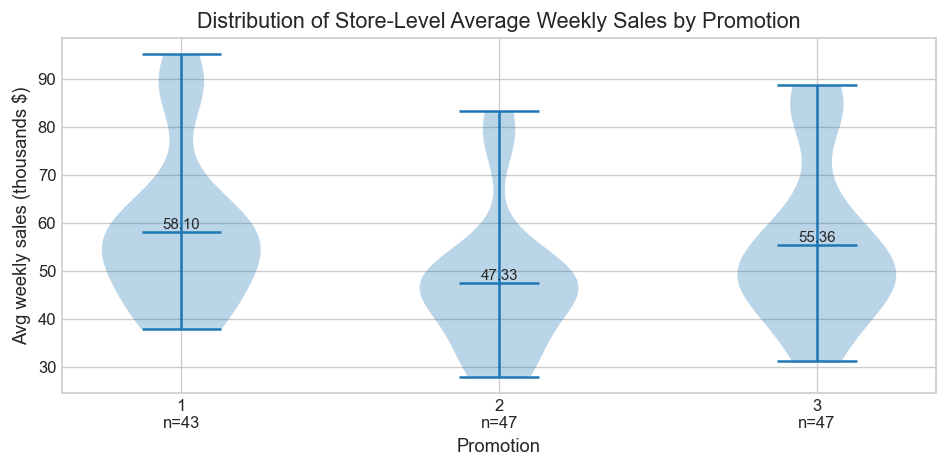

In [11]:
fig = plot_distribution_violin(
    store_level,
    group_col=FAST_FOOD.col_promotion,
    value_col='avg_sales',
    title='Distribution of Store-Level Average Weekly Sales by Promotion',
    xlabel='Promotion',
    ylabel='Avg weekly sales (thousands $)',
    out_name='fast_food_store_level_distribution_by_promo.png',
    order=[1, 2, 3],
)
plt.show()

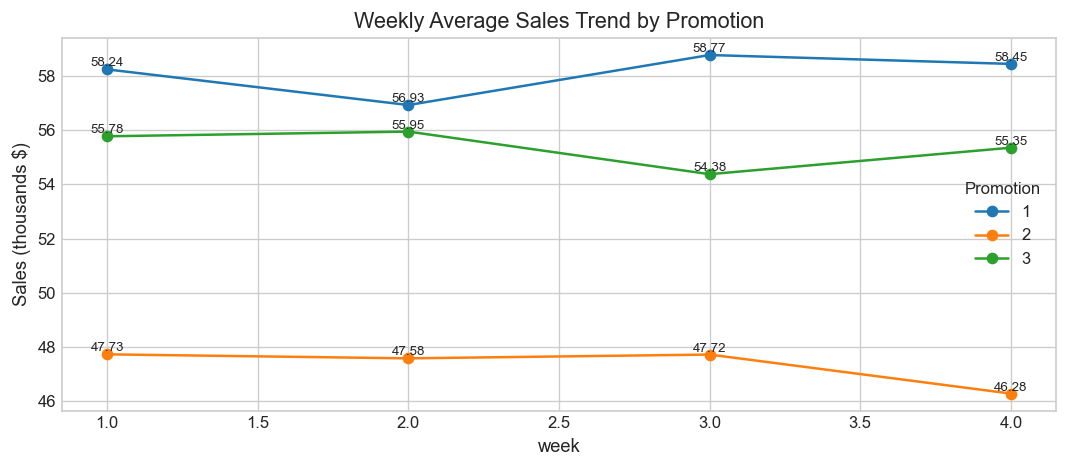

In [12]:
fig = plot_weekly_trend(
    df_clean,
    week_col=FAST_FOOD.col_week,
    group_col=FAST_FOOD.col_promotion,
    value_col=FAST_FOOD.col_sales,
    title='Weekly Average Sales Trend by Promotion',
    ylabel='Sales (thousands $)',
    out_name='fast_food_weekly_trend_by_promo.png',
)
plt.show()

---
## 9. Pairwise A/B Tests

We run all pairwise comparisons for a complete view:
- Promotion 1 vs 2
- Promotion 1 vs 3 (required by review)
- Promotion 2 vs 3 (for completeness)

Each test uses Welch t-test and a bootstrap CI for robustness.

### A/B Test: Promotion 1 vs Promotion 2

- **H0:** Mean store-level average weekly sales is equal between Promotion 1 and 2.
- **H1:** Mean store-level average weekly sales differs.

In [13]:
x12 = store_level.loc[store_level[FAST_FOOD.col_promotion] == 1, 'avg_sales'].to_numpy()
y12 = store_level.loc[store_level[FAST_FOOD.col_promotion] == 2, 'avg_sales'].to_numpy()

ab_1v2 = welch_ttest_mean(x12, y12, group_a='Promo 1', group_b='Promo 2', alpha=alpha)
boot_1v2 = bootstrap_ci_mean_diff(x12, y12, alpha=alpha, n_boot=20000, seed=RANDOM_SEED)

print(f'Promo 1 mean: {ab_1v2.mean_a:.2f}k   (n={ab_1v2.n_a})')
print(f'Promo 2 mean: {ab_1v2.mean_b:.2f}k   (n={ab_1v2.n_b})')
print(f'Difference:   {ab_1v2.diff_a_minus_b:+.2f}k  ({ab_1v2.pct_lift_vs_b:+.1f}%)')
print(f'Welch 95% CI: [{ab_1v2.ci_low:.2f}, {ab_1v2.ci_high:.2f}]')
print(f'Bootstrap CI: [{boot_1v2[0]:.2f}, {boot_1v2[1]:.2f}]')
print(f'p-value:      {ab_1v2.p_value:.4f}')
print(f'Cohen d:      {ab_1v2.cohen_d:.3f}')

Promo 1 mean: 58.10k   (n=43)
Promo 2 mean: 47.33k   (n=47)
Difference:   +10.77k  (+22.8%)
Welch 95% CI: [4.34, 17.20]
Bootstrap CI: [4.58, 17.13]
p-value:      0.0013
Cohen d:      0.705


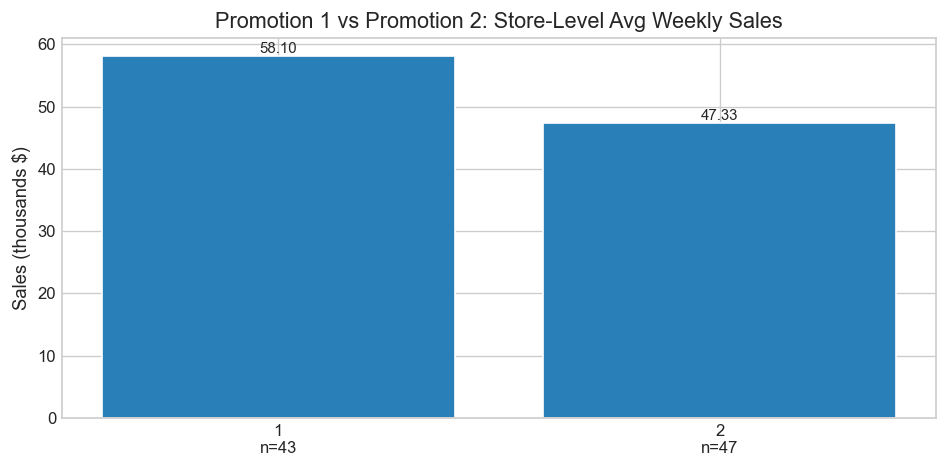

In [14]:
fig = plot_group_mean_bar(
    store_level[store_level[FAST_FOOD.col_promotion].isin([1, 2])],
    group_col=FAST_FOOD.col_promotion,
    value_col='avg_sales',
    title='Promotion 1 vs Promotion 2: Store-Level Avg Weekly Sales',
    ylabel='Sales (thousands $)',
    out_name='fast_food_store_level_mean_p1_vs_p2.png',
    order=[1, 2],
)
plt.show()

### A/B Test: Promotion 1 vs Promotion 3

- **H0:** Mean store-level average weekly sales is equal between Promotion 1 and 3.
- **H1:** Mean store-level average weekly sales differs.

In [15]:
x13 = store_level.loc[store_level[FAST_FOOD.col_promotion] == 1, 'avg_sales'].to_numpy()
y13 = store_level.loc[store_level[FAST_FOOD.col_promotion] == 3, 'avg_sales'].to_numpy()

ab_1v3 = welch_ttest_mean(x13, y13, group_a='Promo 1', group_b='Promo 3', alpha=alpha)
boot_1v3 = bootstrap_ci_mean_diff(x13, y13, alpha=alpha, n_boot=20000, seed=RANDOM_SEED)

print(f'Promo 1 mean: {ab_1v3.mean_a:.2f}k   (n={ab_1v3.n_a})')
print(f'Promo 3 mean: {ab_1v3.mean_b:.2f}k   (n={ab_1v3.n_b})')
print(f'Difference:   {ab_1v3.diff_a_minus_b:+.2f}k  ({ab_1v3.pct_lift_vs_b:+.1f}%)')
print(f'Welch 95% CI: [{ab_1v3.ci_low:.2f}, {ab_1v3.ci_high:.2f}]')
print(f'Bootstrap CI: [{boot_1v3[0]:.2f}, {boot_1v3[1]:.2f}]')
print(f'p-value:      {ab_1v3.p_value:.4f}')
print(f'Cohen d:      {ab_1v3.cohen_d:.3f}')

Promo 1 mean: 58.10k   (n=43)
Promo 3 mean: 55.36k   (n=47)
Difference:   +2.73k  (+4.9%)
Welch 95% CI: [-4.06, 9.53]
Bootstrap CI: [-3.83, 9.40]
p-value:      0.4259
Cohen d:      0.169


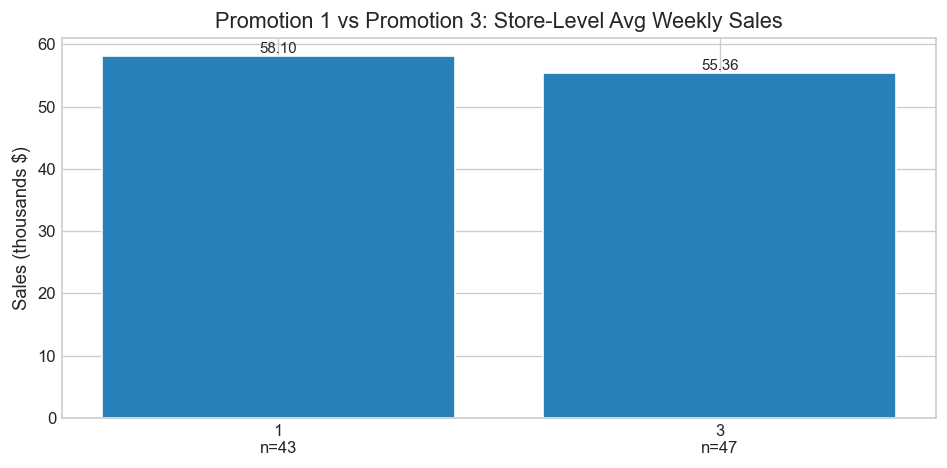

In [16]:
fig = plot_group_mean_bar(
    store_level[store_level[FAST_FOOD.col_promotion].isin([1, 3])],
    group_col=FAST_FOOD.col_promotion,
    value_col='avg_sales',
    title='Promotion 1 vs Promotion 3: Store-Level Avg Weekly Sales',
    ylabel='Sales (thousands $)',
    out_name='fast_food_store_level_mean_p1_vs_p3.png',
    order=[1, 3],
)
plt.show()

---
## 10. A/B/C Global Test

Before comparing all pairs, we run a global omnibus test across all three promotions. If significant, we proceed with Holm-corrected pairwise comparisons.

In [17]:
groups = {
    f'Promotion {p}': store_level.loc[store_level[FAST_FOOD.col_promotion] == p, 'avg_sales'].to_numpy()
    for p in [1, 2, 3]
}
global_res = choose_global_test(groups, alpha=alpha)

print(f'Global test: {global_res.method}')
print(f'Statistic:   {global_res.stat:.3f}')
print(f'p-value:     {global_res.p_value:.4f}')
print()
if global_res.p_value < alpha:
    print('Global test is significant. Proceeding with Holm-corrected pairwise comparisons.')
else:
    print('Global test is NOT significant. No strong evidence that any promotion differs.')

Global test: Kruskal-Wallis
Statistic:   17.327
p-value:     0.0002

Global test is significant. Proceeding with Holm-corrected pairwise comparisons.


In [18]:
if global_res.p_value < alpha:
    posthoc = pairwise_tests(groups, alpha=alpha, p_adjust='holm')
    display(posthoc)
else:
    posthoc = None
    print('Skipping post-hoc comparisons (global test not significant).')

,comparison,n_a,n_b,mean_a,mean_b,diff_a_minus_b,pct_lift_vs_b,ci_low,ci_high,p_value,effect_size,p_adj,significant
0,Promotion 1 vs Promotion 2,43,47,58.099012,47.329415,10.769597,22.754553,4.343367,17.195827,0.001278,0.704731,0.003833,True
2,Promotion 2 vs Promotion 3,47,47,47.329415,55.364468,-8.035053,-14.513014,-14.374041,-1.696066,0.013558,-0.519420,0.027115,True
1,Promotion 1 vs Promotion 3,43,47,58.099012,55.364468,2.734544,4.939167,-4.059348,9.528436,0.425912,0.168726,0.425912,False


---
## 11. Business Impact Estimation

We translate the statistical findings into dollar terms to help stakeholders evaluate whether the lift justifies the cost of the promotion.

In [19]:
# Use Promo 2 as baseline (lowest performer in most comparisons)
promo_means = store_level.groupby(FAST_FOOD.col_promotion)['avg_sales'].mean()
baseline_promo = int(promo_means.idxmin())
best_promo = int(promo_means.idxmax())

baseline_mean = promo_means[baseline_promo]
best_mean = promo_means[best_promo]
lift_k = best_mean - baseline_mean
lift_pct = lift_k / baseline_mean * 100

# Assume 500 stores nationwide for illustration
n_stores_rollout = 500
weekly_lift_total = lift_k * n_stores_rollout  # in thousands
annual_lift_total = weekly_lift_total * 52

print('Business Impact Estimation')
print('=' * 50)
print(f'Best promotion:    Promotion {best_promo} ({best_mean:.2f}k/week/store)')
print(f'Baseline:          Promotion {baseline_promo} ({baseline_mean:.2f}k/week/store)')
print(f'Lift per store:    +{lift_k:.2f}k/week ({lift_pct:+.1f}%)')
print()
print(f'Projected impact (assuming {n_stores_rollout} stores):')
print(f'  Weekly:  +${weekly_lift_total:.0f}k  (= +${weekly_lift_total * 1000:,.0f})')
print(f'  Annual:  +${annual_lift_total:.0f}k  (= +${annual_lift_total * 1000:,.0f})')
print()
print('Note: This is a rough estimate. Actual impact depends on promotion cost,')
print('margin structure, and whether the effect sustains beyond four weeks.')

Business Impact Estimation
Best promotion:    Promotion 1 (58.10k/week/store)
Baseline:          Promotion 2 (47.33k/week/store)
Lift per store:    +10.77k/week (+22.8%)

Projected impact (assuming 500 stores):
  Weekly:  +$5385k  (= +$5,384,798)
  Annual:  +$280010k  (= +$280,009,515)

Note: This is a rough estimate. Actual impact depends on promotion cost,
margin structure, and whether the effect sustains beyond four weeks.


---
## 12. Decision and Recommendation

In [20]:
report = build_fast_food_manager_report(
    store_level,
    promotion_col=FAST_FOOD.col_promotion,
    metric_col='avg_sales',
    alpha=alpha,
    seed=RANDOM_SEED,
    p_adjust='holm',
)

display(Markdown(report.recommendation_md))
print()
print('Group summary:')
display(report.group_summary)
print()
print('Pairwise summary:')
display(report.pairwise_summary)

### Decision
**Recommendation:** Roll out **Promotion 1** based on the highest average store-level weekly sales.

### Evidence
A/B/C global test is significant (Kruskal-Wallis, p = 0.000). Holm correction used for pairwise comparisons.

Pairwise results (Holm-corrected):
- Promotion 1 vs Promotion 2: lift 10.77k, 95% CI [4.34k, 17.20k], adjusted p-value 0.004
- Promotion 1 vs Promotion 3: lift 2.73k, 95% CI [-4.06k, 9.53k], adjusted p-value 0.426
- Promotion 2 vs Promotion 3: lift -8.04k, 95% CI [-14.37k, -1.70k], adjusted p-value 0.027

### Next steps
- Confirm promotion cost and margin impact (sales alone may not maximize profit)
- If differences are small or not significant, run a longer test or add more stores
- Monitor rollout with guardrail metrics (operational load, customer satisfaction)


Group summary:


,Promotion,stores,avg_weekly_sales_k,median_k,std_k
0,1,43,58.099012,56.0750,16.028223
1,2,47,47.329415,46.6550,14.497097
2,3,47,55.364468,49.8525,16.383866



Pairwise summary:


,comparison,n_a,n_b,mean_a,mean_b,pct_lift_vs_b,ci_low,ci_high,p_adj,significant
0,Promotion 1 vs Promotion 2,43,47,58.099012,47.329415,22.754553,4.343367,17.195827,0.003833,True
2,Promotion 2 vs Promotion 3,47,47,47.329415,55.364468,-14.513014,-14.374041,-1.696066,0.027115,True
1,Promotion 1 vs Promotion 3,43,47,58.099012,55.364468,4.939167,-4.059348,9.528436,0.425912,False


---
## 13. Dashboard

A four-panel executive summary combining the key visuals from this analysis. Panel 1 shows the **weekly sales trend by promotion** (required). Panels 2-4 provide the store-level comparison, distribution, and pairwise lift table.


In [21]:
fig = dashboard_fast_food(
    df_clean,
    store_level,
    promotion_col=FAST_FOOD.col_promotion,
    sales_col=FAST_FOOD.col_sales,
    week_col=FAST_FOOD.col_week,
)
fig.show()

---
## 14. Limitations

1. **Short test window.** Only four weeks of data, so seasonal effects are not captured. The promotion effect may not sustain long-term.
2. **Randomization assumption.** We assume promotion assignment is effectively random across stores. If assignment was non-random, covariate imbalance could bias results. The balance check (Section 7) partially addresses this.
3. **Store-level aggregation.** Averaging over weeks reduces within-store temporal variation but still ignores trends within the four-week window.
4. **No cost data.** Sales lift alone does not determine profitability. The cost of running each promotion is needed to compute ROI.
5. **Single chain, single region.** Results may not generalize to other restaurant chains or geographies.